<a href="https://colab.research.google.com/github/zaffaazz/DKA/blob/main/Jurnal_Mod5_DKA_Genap_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align='center'>
    <h1>Jurnal Praktikum Dasar Kecerdasan Artifisial</h1>
    <h3>Modul 5: Breadth First Search (BFS)</h3>
</div>

### Tujuan Praktikum
- Mahasiswa memahami dan mampu mengimplementasikan algoritma *Breadth-First Search* pada Python dengan menggunakan *library* NetworkX.

## Petunjuk Umum
1. **Jangan lupa untuk selalu import *library* NetworkX & Matplotlib ketika memulai sesi baru (run time) atau kode Python yang memerlukan penggunaan library NetworkX**
2. **Jangan ubah struktur kode yang diberikan, cukup isi bagian yang kosong.**
3. **Jalankan setiap sel satu per satu agar tidak ada error.**
4. **Kerjakan soal yang ada secara berurutan, dikarenakan soal akan meneruskan code soal sebelumnya**

In [3]:
print("Zaffa Azzahra")  # Tuliskan nama lengkap Anda
print("103112400212")  # Tuliskan NIM Anda
print("IF-12-06")  # Tuliskan kelas Anda
print("https://colab.research.google.com/drive/1lJG7XE-OHA9lvEagUAADglHEN8YP42C-#scrollTo=fSelyjWlVzEq") # Link Collab Praktikum
print("https://colab.research.google.com/drive/1kqazJX8pIbv8zDYOGYezY39AU9MKVA5D#scrollTo=mSIltty2YrfG") # Link Collab Jurnal

Zaffa Azzahra
103112400212
IF-12-06
https://colab.research.google.com/drive/1lJG7XE-OHA9lvEagUAADglHEN8YP42C-#scrollTo=fSelyjWlVzEq
https://colab.research.google.com/drive/1kqazJX8pIbv8zDYOGYezY39AU9MKVA5D#scrollTo=mSIltty2YrfG


In [4]:
import networkx as nx # Library untuk membuat graf
import matplotlib.pyplot as plt # Library untuk plot grafik

### Fungsi pendukung untuk mencetak graf

#### **!! Tidak usah dimodifikasi !!**

In [5]:
# Posisi node
pos = {
    'Jakarta': (-4, 2),
    'Cirebon': (-1, 1),
    'Bandung': (-3, -1),
    'Semarang': (1, 0),
    'Yogyakarta': (0, -2),
    'Surakarta': (3, -1),
    'Surabaya': (5, 0),
    'Malang': (5, -2),
}

In [6]:
# Support function to print the graph
def show_graph(G, pos=None, title=''):
    # If position is not specified from the parameter it will generate a new position
    if pos is None:
        # Generate spring layout if not provided
        pos = nx.spring_layout(G)

    # Ukuran figure dibuat
    plt.figure(figsize=(14, 6))

    # Plot the graph G given in the parameter
    nx.draw(G, pos, with_labels=True, node_color='red', node_size=6000,
            font_color="white", font_weight="bold", width=5)

    # Retrieve each weight of each edge in graph G
    edge_labels = nx.get_edge_attributes(G, "weight")

    # Draw the weight of the edge in the visualization
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue',
                                font_weight="bold", font_size=12)

    # Add margins on each side
    plt.margins(0.2)
    # Add a title as given by the parameter
    plt.title(title)
    # Display the graph visualization on the terminal
    plt.show()

### 1. Implementasi BFS `(Arsitektur Dasar)` (40)

Dora adalah seorang penjelajah yang suka berpetualang di kota-kota baru. Kali ini, Dora mengunjungi beberapa kota. Kota ini memiliki beberapa titik penting, seperti Jakarta, Cirebon, Bandung, Semarang, Yogyakarta, Surakarta, Surabaya, dan Malang. Semua titik ini dihubungkan oleh jalan dengan jarak tertentu yang diukur dalam kilometer. Dora ingin mengetahui rute terpendek yang harus ia tempuh dari satu titik ke titik lainnya menggunakan jalan yang ada.

Bantu Dora untuk membuat program Python yang dapat membantu Dora dengan membuat graf dengan langkah-langkah berikut:

**a. (5 poin)** Inisialisasi graf bernama `kota` menggunakan **graf tidak berarah** untuk menunjukkan arah perjalanan.

In [11]:
kota = nx.Graph()

Kode di atas menjelaskan tentang membuat inisalisai graf tidak berarah dengan nama "kota"

**b. (7 poin)** Tambahkan node untuk merepresentasikan setiap lokasi penting. Berikut ini adalah daftar node yang perlu ditambahkan ke dalam graf:
- `Jakarta`
- `Cirebon`
- `Bandung`
- `Semarang`
- `Yogyakarta`
- `Surakarta`
- `Surabaya`
- `Malang`

Pastikan semua node tersebut ditambahkan ke dalam graf sehingga setiap lokasi dapat direpresentasikan dengan baik dan nantinya dapat dihubungkan oleh edge untuk menunjukkan rute di antara lokasi-lokasi tersebut.

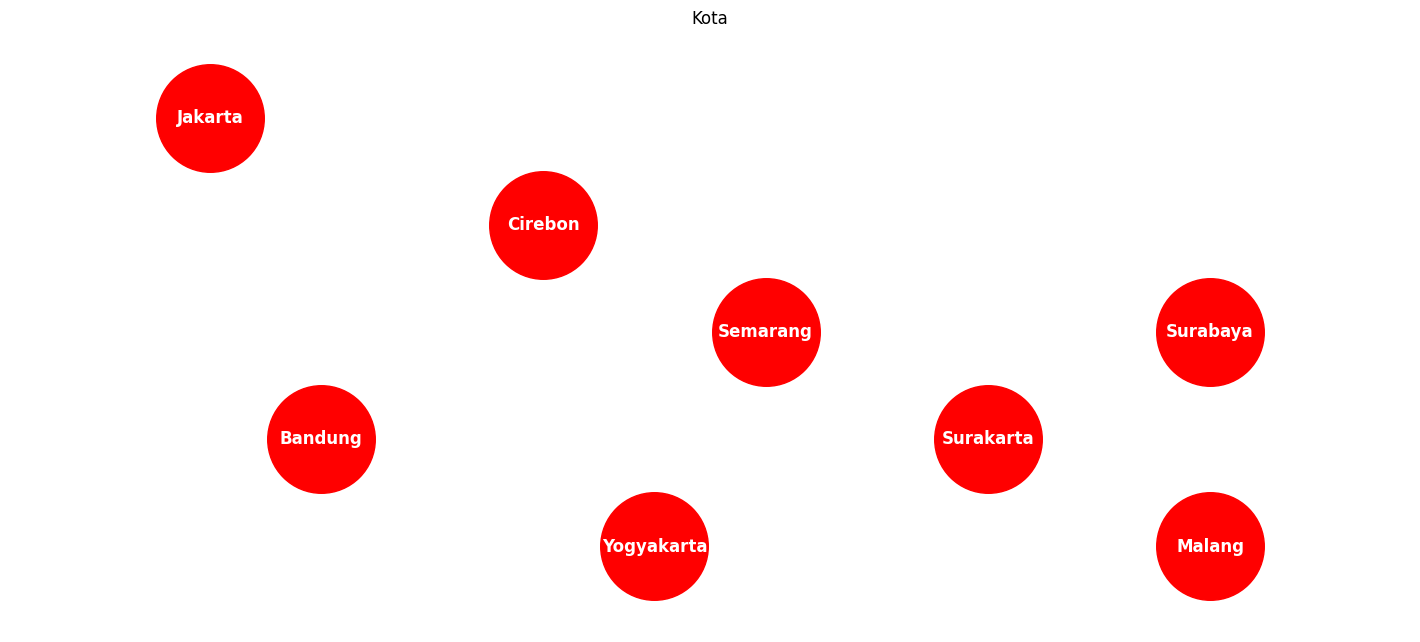

In [13]:
# List daftar nama lokasi di kota BojongCity
nodes = ["Jakarta", "Cirebon", "Bandung", "Semarang", "Yogyakarta", "Surakarta", "Surabaya", "Malang"
]

# Tambahkan node dari list variabel `nodes` pada graf kota
kota.add_nodes_from(nodes)

# Tampilkan graf kota setelah penambahan node
show_graph(kota, pos, title="Kota")

Kode di atas menjelaskan tentang membuat node pada sebuah graf dengan nama lokasi di bojongCity dengan menggunakan perintah "kota.add_nodes_from(nodes)" digunakan untuk menambahkan seluruh nama lokasi yang ada dalam list nodes ke dalam graf.

Contoh *output*:

![Contoh output penambahan lokasi](./asset/1_tambahlokasi_kota.png)

**c. (10 poin)** Pada graf kota, setiap edge mewakili hubungan antara dua lokasi, dan masing-masing hubungan memiliki jarak tempuh tertentu yang direpresentasikan sebagai `weight` pada graf. Berikut ini adalah daftar jarak antar lokasi yang ada di kota tersebut:

- `Jakarta` ke `Bandung` memiliki jarak `270km`.
- `Jakarta` ke `Cirebon` memiliki jarak `327km`.
- `Bandung` ke `Cirebon` memiliki jarak `120km`.
- `Bandung` ke `Yogyakarta` memiliki jarak `373km`.
- `Cirebon` ke `Semarang` memiliki jarak `305km`.
- `Cirebon` ke `Yogyakarta` memiliki jarak `210km`.
- `Yogyakarta` ke `Surakarta` memiliki jarak `60km`.
- `Semarang` ke `Yogyakarta` memiliki jarak `109km`.
- `Semarang` ke `Surakarta` memiliki jarak `97km`.
- `Semarang` ke `Surabaya` memiliki jarak `368km`.
- `Surakarta` ke `Malang` memiliki jarak `370km`.
- `Surabaya` ke `Malang` memiliki jarak `94km`.

Tugas Anda adalah menambahkan edge ke dalam graf untuk setiap hubungan lokasi yang terdaftar di atas. Pastikan setiap edge mencakup informasi jarak tempuh (weight) sebagai atribut tambahan.

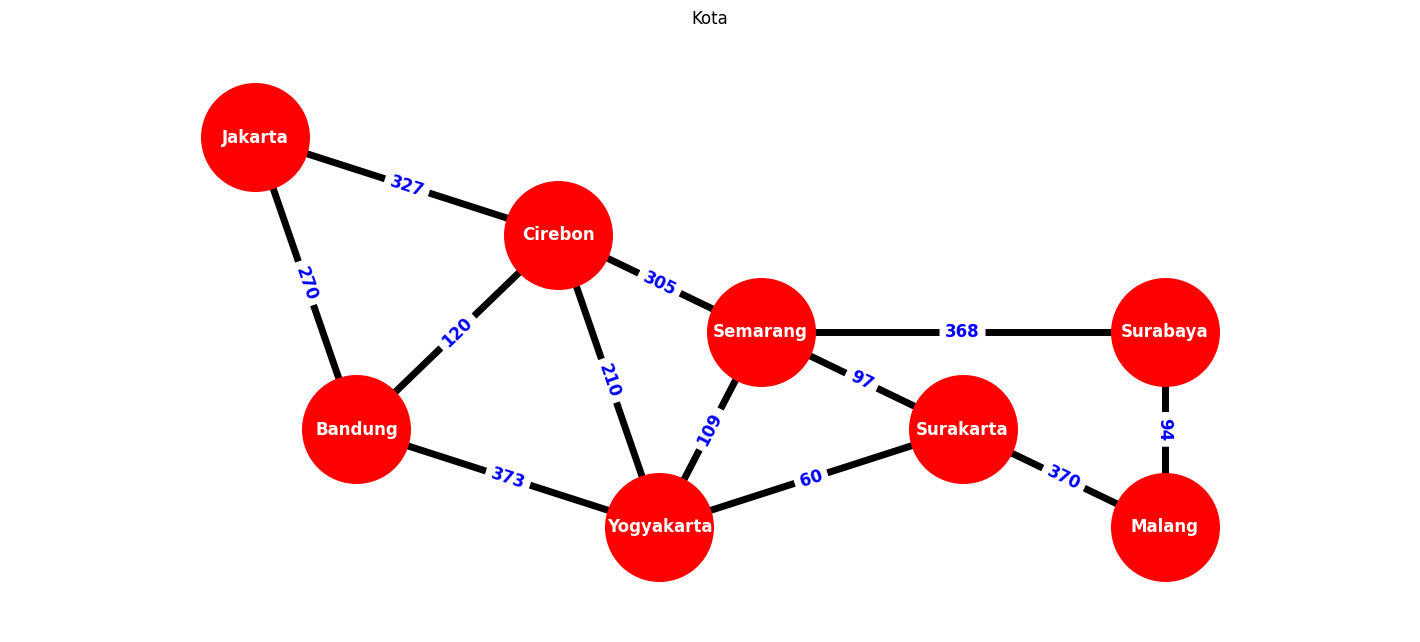

In [14]:
# Daftar hubungan (edge) antar lokasi di beserta jarak tempuh (weight) masing-masing
edges = [
    ("Jakarta", "Bandung", 270),
    ("Jakarta", "Cirebon", 327),
    ("Bandung", "Cirebon", 120),
    ("Bandung", "Yogyakarta", 373),
    ("Cirebon", "Semarang", 305),
    ("Cirebon", "Yogyakarta", 210),
    ("Yogyakarta", "Surakarta", 60),
    ("Semarang", "Yogyakarta", 109),
    ("Semarang", "Surakarta", 97),
    ("Semarang", "Surabaya", 368),
    ("Surakarta", "Malang", 370),
    ("Surabaya", "Malang", 94)
]

# Tambahkan edge beserta weightnya ke dalam graf kota
for u, v, w in edges:
    kota.add_edge(u, v, weight=w)

# Tampilkan graf kota setelah penambahan edge
show_graph(kota, pos, title="Kota")

Kode di atas menjelaskan tentang menambahkan weight (jarak) untuk setiap node yang ada di graf dengan menggunakan perintah
" for u, v, w in edges:
    kota.add_edge(u, v, weight=w)"
untuk membaca setiap pasangan kota (u, v) dan jaraknya w dari list edges, kemudian menambahkannya ke dalam graf sebagai hubungan antar node.

Contoh *output*:

![Contoh output penambahan lokasi](./asset/2_tambahjarak_kota.png)

**d. (10 poin)** Pada potongan kode dibawah, buat program yang menampilkan informasi berikut:

- **Daftar semua nama lokasi kota yang terdapat pada Graf**: Program menampilkan output daftar lengkap lokasi pada graf.
- **Jarak antar lokasi**: Program ini menampilkan output setiap hubungan antara dua lokasi dan mencantumkan jarak tempuh dalam satuan kilometer.

In [15]:
print("Elemen pada Graf kota")
# Menampilkan daftar semua lokasi (node) yang terdapat pada graf kota
print("Daftar lokasi yang terdapat pada kota",  list(kota.nodes()))

print() # Menambahkan baris kosong (biarkan kosong)

# Loop melalui setiap edge pada graf untuk menampilkan informasi jarak (weight) antar lokasi
# Setiap edge memiliki format (asal, tujuan, data), di mana `data` menyimpan atribut dari edge tersebut.
for asal, tujuan, data in kota.edges(data=True):
    print(f"{asal} ↔ {tujuan} : {data['weight']} km")

Elemen pada Graf kota
Daftar lokasi yang terdapat pada kota ['Jakarta', 'Cirebon', 'Bandung', 'Semarang', 'Yogyakarta', 'Surakarta', 'Surabaya', 'Malang']

Jakarta ↔ Bandung : 270 km
Jakarta ↔ Cirebon : 327 km
Cirebon ↔ Bandung : 120 km
Cirebon ↔ Semarang : 305 km
Cirebon ↔ Yogyakarta : 210 km
Bandung ↔ Yogyakarta : 373 km
Semarang ↔ Yogyakarta : 109 km
Semarang ↔ Surakarta : 97 km
Semarang ↔ Surabaya : 368 km
Yogyakarta ↔ Surakarta : 60 km
Surakarta ↔ Malang : 370 km
Surabaya ↔ Malang : 94 km


Contoh *output*:

```
Elemen pada Graf kota
Daftar lokasi yang terdapat pada kota ['Jakarta', 'Cirebon', 'Bandung', 'Semarang', 'Yogyakarta', 'Surakarta', 'Surabaya', 'Malang']

Jakarta ke Bandung memiliki jarak 270 km
Jakarta ke Cirebon memiliki jarak 327 km
Cirebon ke Bandung memiliki jarak 120 km
Cirebon ke Semarang memiliki jarak 305 km
Cirebon ke Yogyakarta memiliki jarak 210 km
Bandung ke Yogyakarta memiliki jarak 373 km
Semarang ke Yogyakarta memiliki jarak 109 km
Semarang ke Surakarta memiliki jarak 97 km
Semarang ke Surabaya memiliki jarak 368 km
Yogyakarta ke Surakarta memiliki jarak 60 km
Surakarta ke Malang memiliki jarak 370 km
Surabaya ke Malang memiliki jarak 94 km
```

Kode di atas menjelaskan tentang daftar lokasi yang terdaat pada graf beserta weightnya dengan menggunakan perintah "for asal, tujuan, data in kota.edges(data=True):
    print(f"{asal} ↔ {tujuan} : {data['weight']} km")"
maka akan menunjukan dua kota yang terhubung beserta dengen weigh yang tertera dalam graf.
    

**e. (8 poin)** Dora ingin mengetahui urutan perjalanan menggunakan algoritma `Breadth-First Search (BFS)`, dimulai dari `Semarang` sebagai titik awal. Tugas anda adalah menampilkan daftar **edge** yang dilalui oleh algoritma BFS saat menjelajahi semua lokasi di kota, mulai dari node `Semarang`.

In [16]:
print(list(nx.bfs_edges(kota, source="Semarang")))  # menampilkan BFS dari kota Semarang menggunakan bfs_edges

[('Semarang', 'Cirebon'), ('Semarang', 'Yogyakarta'), ('Semarang', 'Surakarta'), ('Semarang', 'Surabaya'), ('Cirebon', 'Jakarta'), ('Cirebon', 'Bandung'), ('Surakarta', 'Malang')]


Contoh *output*:

```
[('Semarang', 'Cirebon'), ('Semarang', 'Yogyakarta'), ('Semarang', 'Surakarta'), ('Semarang', 'Surabaya'), ('Cirebon', 'Jakarta'), ('Cirebon', 'Bandung'), ('Surakarta', 'Malang')]
```

Kode di atas menjelaskan tentang perncarian dengan menggunakn algoritma Breadth-First Search (BFS) dengan menggunakan perintah "nx.bfs_edges(kota, source="Semarang") maka akan menghasikan urutan pasangan node yang terhubung dengan kota semarang.

### 2. Implementasi BFS `(Pencarian dengan Bobot)` (60)

**a. (10 poin)** Buatlah sebuah program yang meminta input dari pengguna untuk menentukan:
- **Node awal** (`start_node`): Titik awal perjalanan Dora..
- **Node tujuan** (`end_node`): Titik tujuan yang ingin dicapai oleh Dora.

Gunakan algoritma BFS untuk menelusuri graf yang mewakili kota, dimulai dari `start_node`. Simpan hasil BFS dalma bentuk pasang node (`bfs_edges`) yang menunjukkan jalur pencarian dari node awal ke node-node yang terhubung.

Tampilkan hasil pencarian BFS (`bfs_edge`) yang menunjukkan semua node yang dikunjungi dan hubungan antar node yang ditemukan selama pencarian BFS dimulai dari `start_node`.

In [23]:
def jalan_jalan():
    # Minta input dari pengguna untuk titik awal dan titik tujuan
    start_node  = input("Masukkan node awal: ")
    end_node = input("Masukkan node tujuan: ")

    # Temukan rute BFS dari node awal
    bfs_edges = list(nx.bfs_edges(kota, source=start_node))

    print(f"Kota {start_node} lokasi awal perjalanan")
    print(f"Kota {end_node} lokasi tujuan akhir perjalanan")
    print(f"Hasil pencarian BFS dari lokasi awal: {bfs_edges}")

In [24]:
jalan_jalan()

Masukkan node awal: Semarang
Masukkan node tujuan: Surabaya
Kota Semarang lokasi awal perjalanan
Kota Surabaya lokasi tujuan akhir perjalanan
Hasil pencarian BFS dari lokasi awal: [('Semarang', 'Cirebon'), ('Semarang', 'Yogyakarta'), ('Semarang', 'Surakarta'), ('Semarang', 'Surabaya'), ('Cirebon', 'Jakarta'), ('Cirebon', 'Bandung'), ('Surakarta', 'Malang')]


In [25]:
jalan_jalan()

Masukkan node awal: Jakarta
Masukkan node tujuan: Surakarta
Kota Jakarta lokasi awal perjalanan
Kota Surakarta lokasi tujuan akhir perjalanan
Hasil pencarian BFS dari lokasi awal: [('Jakarta', 'Bandung'), ('Jakarta', 'Cirebon'), ('Bandung', 'Yogyakarta'), ('Cirebon', 'Semarang'), ('Yogyakarta', 'Surakarta'), ('Semarang', 'Surabaya'), ('Surakarta', 'Malang')]


Contoh *output*:

|input|output|
|-----|------|
|Masukan titik awal: `Semarang`<br>Masukkan titk tujuan: `Surabaya`|Kota Semarang lokasi awal perjalanan<br>Kota Surabaya lokasi tujuan akhir perjalanan<br>Hasil pencarian BFS dari lokasi awal: [('Semarang', 'Cirebon'), ('Semarang', 'Yogyakarta'), ('Semarang', 'Surakarta'), ('Semarang', 'Surabaya'), ('Cirebon', 'Jakarta'), ('Cirebon', 'Bandung'), ('Surakarta', 'Malang')]|
|Masukan titik awal: `Jakarta`<br>Masukkan titk tujuan: `Surakarta`|Kota Jakarta lokasi awal perjalanan<br>Kota Surakarta lokasi tujuan akhir perjalanan<br>Hasil pencarian BFS dari lokasi awal: [('Jakarta', 'Bandung'), ('Jakarta', 'Cirebon'), ('Bandung', 'Yogyakarta'), ('Cirebon', 'Semarang'), ('Yogyakarta', 'Surakarta'), ('Semarang', 'Surabaya'), ('Surakarta', 'Malang')]|

Kode di atas menjelaskan tentang fungsi jalan_jalan() yang meminta pengguna memasukkan node awal dan node tujuan, kemudian menjalankan algoritma BFS mulai dari node awal dengan menggunakan perintah "bfs_edges = list(nx.bfs_edges(kota, source=start_node))" maka akan menghasilkan urusan edge yang di lewati dalam graf.

**b. (10 poin)** Buatlah deskripsi dictionary bernama `bfs_tree` yang menyimpan hubungan parent-child dari hasil BFS, Setiap key dalam dictionary `bfs_tree` mewakili node child (tujuan), dan value-nya mewakili node parent (asal).

Gunakan pasangan node (`u`, `v`) yang diberikan oleh `bfs_edges` untuk membangun `bfs_tree`. Setiap pasangan(`u`, `v`) berarti :
- `u` adalah parent dari `v`.
- `v` adalah child dari `u`.

In [27]:
# Buat dictionary untuk melacak jalur dari titik awal ke semua node yang dikunjungi
def pencarian_simpul_BFS(kota, source):
    bfs_edges = list(nx.bfs_edges(kota, source=source))
    print(f"Hasil BFS traversal kota {None}")
    for u, v in bfs_edges:
        print(f"{u} -> {v}")


In [29]:
masukan = input("Masukkan kota awal: ")
pencarian_simpul_BFS(kota, masukan)

Masukkan kota awal: Semarang
Hasil BFS traversal kota None
Semarang -> Cirebon
Semarang -> Yogyakarta
Semarang -> Surakarta
Semarang -> Surabaya
Cirebon -> Jakarta
Cirebon -> Bandung
Surakarta -> Malang


In [30]:
masukan = input("Masukkan kota awal: ")
pencarian_simpul_BFS(kota, masukan)

Masukkan kota awal: Surabaya
Hasil BFS traversal kota None
Surabaya -> Semarang
Surabaya -> Malang
Semarang -> Cirebon
Semarang -> Yogyakarta
Semarang -> Surakarta
Cirebon -> Jakarta
Cirebon -> Bandung


*Test case Program*:

|input|output|
|-----|------|
|Masukan kota awal: `Semarang`|Hasil BFS traversal kota Semarang: <br> Semarang -> Cirebon <br>Semarang -> Yogyakarta <br>Semarang -> Surakarta <br>Semarang -> Surabaya <br>Cirebon -> Jakarta <br>Cirebon -> Bandung <br>Surakarta -> Malang|
|Masukan kota awal: `Surabaya`|Hasil BFS traversal kota Surabaya: <br> Surabaya -> Semarang<br>Surabaya -> Malang<br>Semarang -> Cirebon<br>Semarang -> Yogyakarta<br>Semarang -> Surakarta<br>Cirebon -> Jakarta<br>Cirebon -> Bandung|

Kode di atas menjelaskan tentang pembuatan fungsi pencarian_simpul_BFS() yang digunakan untuk menampilkan hasil penelusuran Breadth-First Search (BFS) dari sebuah node awal (source) dengan menggunakan beberapa perintah "bfs_edges = list(nx.bfs_edges(kota, source=source))" untuk mengambil semua pasangan parent-child dalam graf.

**c. (15 poin)** Buatlah sebuah fungsi `bfs_search(bfs_tree, start, end)` yang dapat membangun jalur dari node awal (`start`) dan node tujuan (`end`) berdasarkan struktur `bfs_tree` yang diberikan.

Fungsi `bfs_search()` harus melakukan langkah-langkah berikut :
- Mulai dari `end` dan telusuri mundur ke `start` menggunakan informasi `parent-child` pada `bfs_tree`.
- Simpan jalur yang ditemukan pada list `path`
- Jika node `start` berhasil ditemukan, kembalikan `path` yang menunjukkan urutan dari node `start` ke `end`.

In [35]:
def bfs_search(bfs_tree, start_node, end_node):
    # Inisialisasi list kosong untuk menampung jalur yang ditempuh
    path = []

    # Mulai dari node tujuan, karena bfs_tree merepresentasikan hubungan parent-child
    current_node = end_node

    # Telusuri jalur mundur dari node tujuan hingga mencapai node awal (start)
    while current_node != start_node: # Jika node sekarang tidak sama dengan node start
        path.append(current_node)   # Tambahkan node ke dalam jalur
        current_node = bfs_tree[current_node]  # Pindah ke node sebelumnya (parent) dalam jalur

    # Tambahkan node awal setelah mencapai start
    path.append(start_node)
    path.reverse()  # Balikkan urutan jalur agar sesuai dari start ke end menggunakan reverse()

    return path

Pada kode di atas menjelaskan tentang mencari jalur awal sampai jalur tujuan bedasarkan bsf tree dengan menggunakan perintah " while current_node != start_node:
    path.append(current_node)
    current_node = bfs_tree[current_node]"
maka akan mencari jalur dalam parent pada sebuah tree.

**d. (10 poin)** Buatlah sebuah fungsi `calculate_total_distance(graph, path)` yang akan menghitung total jarak tempuh dari jalur `path` pada graf `graph`. Berikut adalah langkah-langkah yang harus dilakukan dalam fungsi `calculate_total_distance()`:
- Inisialisasi variabel `total_distance` sebagai 0.
- Lakukan loop untuk mengiterasi pada setiap node pada `path` (kecuali node terakhir).
- Ambil jarak tempuh dari edge yang menghubungkan node saat ini (`node_awal`) ke node berikutnya (`node_tujuan`).
- Tambahkan weight tersebut ke dalam `total_distance`.

In [36]:
# Fungsi untuk menghitung total jarak dari node awal ke tujuan
def calculate_total_distance(graph, path):
    total_distance = 0  # Inisialisasi jarak total

    # Loop melalui setiap node dalam path dan jumlahkan weight dari setiap edge yang dilalui
    for i in range(len(path) - 1):
        node_awal = path[i]       # Node awal dari path
        node_tujuan = path[i + 1] # Node tujuan dari path

        # Tambahkan weight dari edge ke total distance
        total_distance += graph[node_awal][node_tujuan]['weight']

    return total_distance  # return total distance yang telah diperoleh

Kode di atas menjelaskan tentang menghitung total jarak tempuh dari jalur yang telah ditemukan, dengan menggunakan fungsi "total_distance():" Fungsi ini menjumlahkan seluruh weight pada setiap edge yang dilalui di dalam path, sehingga menghasilkan total jarak perjalanan dari node awal sampai node tujuan.

**e. (15 poin)** Sekarang, Dora ingin mengetahui rute terpendek dari lokasi awal (`kota_awal`) ke lokasi tujuan (`kota_tujuan`) berdasarkan hasil penelusuran BFS tersebut. Selain itu, Dora juga ingin mengetahui tempat mana saja yang harus ia kunjungi. Selain itu, Dora juga ingin mengetahui total jarak tempuh dari jalur yang ditemukan agar ia dapat mempersiapkan dirinya.

Buatlah program yang dapat menemukan rute terpendek dari node awal ke node tujuan menggunakan hasil penelurusan `bfs_tree` yang sudah dibuat dan program untuk menghitung total jarak tembuh dari jalu tersebut berdasarkan `weight` dari setiap edge yang dilalui dengan langkah-langkah berikut:
- Gunakan fungsi `bfs_search()` untuk menemukan rute dari `kota_awal` ke `kota_tujuan`.
- Jika terdapat jalur dari `kota_awal` ke `kota_tujuan`, hitung total jarak tempuh dari jalur tersebut menggunakan fungsi `calculate_total_distance()`.
- Tampilkan rute terpendek dan total jarak tempuh yang ditemukan.

In [39]:
def calculate_shortest_city():
    kota_awal = input("Masukkan titik awal: ")   # start node
    kota_tujuan = input("Masukkan titik tujuan: ")  # end node

    bfs_edges = list(nx.bfs_edges(kota, kota_awal))

    bfs_tree = {}
    for u, v in bfs_edges:
        bfs_tree[v] = u  # simpan parent dari setiap node

    # Temukan jalur dari titik awal ke titik tujuan
    shortest_path = bfs_search(bfs_tree, kota_awal, kota_tujuan)

    # Jika jalur ditemukan, hitung total jarak berdasarkan rute
    if shortest_path:
      total_distance = calculate_total_distance(kota, shortest_path)
      print(f"Rute terpendek dari {kota_awal} ke {kota_tujuan}: {shortest_path}")
      print(f"Total jarak tempuh: {total_distance} km")
    else:
      print(f"Tidak ada jalur dari {kota_awal} ke {kota_tujuan}")

In [40]:
calculate_shortest_city()

Masukkan titik awal: Bandung
Masukkan titik tujuan: Malang
Rute terpendek dari Bandung ke Malang: ['Bandung', 'Yogyakarta', 'Surakarta', 'Malang']
Total jarak tempuh: 803 km


In [41]:
calculate_shortest_city()

Masukkan titik awal: Semarang
Masukkan titik tujuan: Jakarta
Rute terpendek dari Semarang ke Jakarta: ['Semarang', 'Cirebon', 'Jakarta']
Total jarak tempuh: 632 km


*Test case Program*:

|input|output|
|-----|------|
|Masukan titik awal: `Bandung`<br>Masukan titik tujuan: `Malang`|Rute terpendek dari Bandung ke Malang: ['Bandung', 'Yogyakarta', 'Surakarta', 'Malang']<br>Total jarak tempuh: 803 km|
|Masukan titik awal: `Semarang`<br>Masukan titik tujuan: `Jakarta`|Rute terpendek dari Semarang ke Jakarta: ['Semarang', 'Cirebon', 'Jakarta']<br>Total jarak tempuh: 632 km|

Kode di atas menjelaskan tentang fungsi calculate_shortest_city() yang digunakan untuk mencari dan menampilkan rute terpendek dari sebuah kota awal ke kota tujuan berdasarkan hasil penelusuran Breadth-First Search (BFS). dengan menggunakan perintah "nx.bfs_edges(kota, kota_awal)" digunakan untuk melakukan penelusuran BFS dari node awal dan menghasilkan pasangan parent dan child, "bfs_search(bfs_tree, kota_awal, kota_tujuan)" digunakan untuk membangun kembali jalur dari kota awal ke kota tujuan berdasarkan tree, dan "calculate_total_distance(kota, shortest_path)" digunakan untuk menghitung total jarak tempuh dari jalur yang didapat.